### 0: Project Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import os
import joblib

sns.set_style("whitegrid")

RANDOM_STATE = 42

In [2]:
# Load Data

# تعریف مسیرهای نسبی با امنیت بالا
BASE_DIR = os.path.dirname(os.getcwd()) # رفتن به پوشه اصلی پروژه از داخل پوشه notebooks
DATA_DIR = os.path.join(BASE_DIR, "data")

train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

# Load Data
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

### 1: Understanding the Data

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# بررسی تعداد سطرها و ستون‌ها
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (891, 12)
Test shape: (418, 11)


In [6]:
# مشاهده نام ستون‌ها

train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
# بررسی نوع داده هر ستون و مقدار داده‌های missing

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
# خلاصه آماری featureهای عددی

train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# تعداد مقادیر missing در هر ستون

test.isnull().sum().sort_values(ascending=False)

Cabin          327
Age             86
Fare             1
Name             0
Pclass           0
PassengerId      0
Sex              0
Parch            0
SibSp            0
Ticket           0
Embarked         0
dtype: int64

پس میفهمیم cabin تقریبا useless و Age نیاز به imputation دارد

In [10]:
# بررسی تعداد مرد و زن

train["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [11]:
train["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

### 2: Target Analysis

In [12]:
# برسی توزیع Target
# بررسی تعداد افراد زنده مانده و فوت شده
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [13]:
train["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [14]:
# درصد افراد زنده مانده

survival_rate = train["Survived"].mean()

print("Survival Rate:", survival_rate)

Survival Rate: 0.3838383838383838


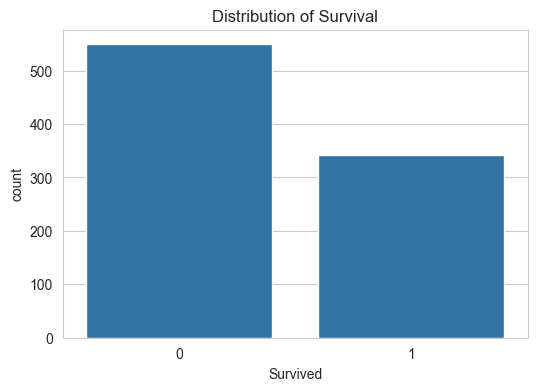

In [15]:
# نمودار تعداد افراد زنده مانده و فوت شده

plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="Survived"
)

plt.title("Distribution of Survival")
plt.show()

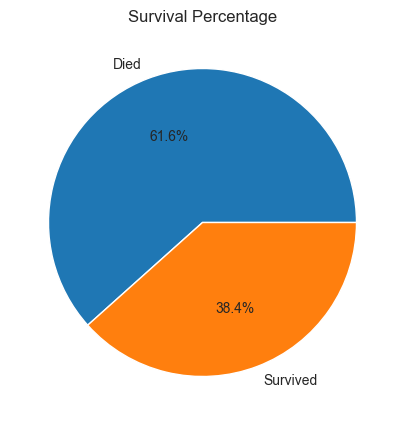

In [16]:
# نمودار دایره‌ای برای survival rate

train["Survived"].value_counts().plot.pie(
    autopct="%1.1f%%",
    labels=["Died", "Survived"],
    figsize=(5,5)
)

plt.title("Survival Percentage")
plt.ylabel("")
plt.show()

### 3: EDA: Exploratory Data Analysis

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


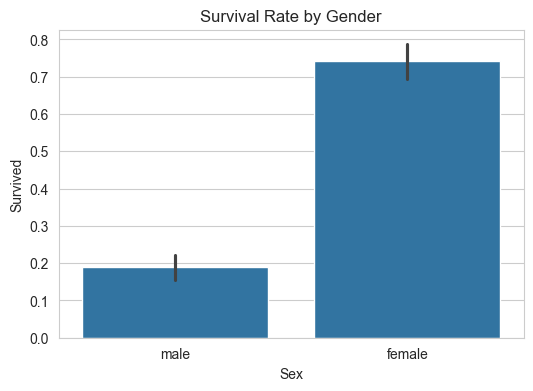

In [17]:
# 3.1: Gender Analysis

# Survival by Gender
print((train.groupby("Sex")["Survived"].mean()))

# ----------------------------------------------

# نمودار Sex vs Survival
plt.figure(figsize=(6,4))

sns.barplot(
    data=train,
    x="Sex",
    y="Survived"
)

plt.title("Survival Rate by Gender")
plt.show()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


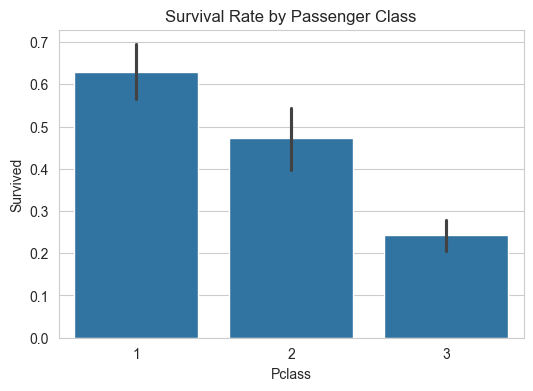

In [18]:
# 3.2: Passenger Class Analysis

# Survival by Class
# Pclass --> Ticket class
print(train.groupby("Pclass")["Survived"].mean())

# -----------------------------------------------

# نمودار Pclass vs Survival
plt.figure(figsize=(6,4))

sns.barplot(
    data=train,
    x="Pclass",
    y="Survived"
)

plt.title("Survival Rate by Passenger Class")
plt.show()

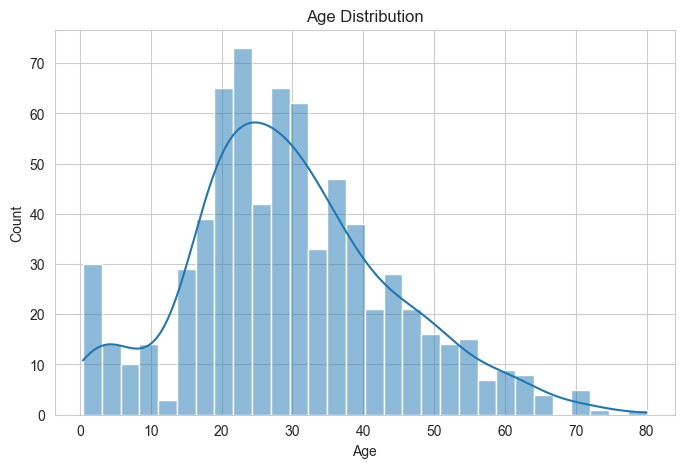

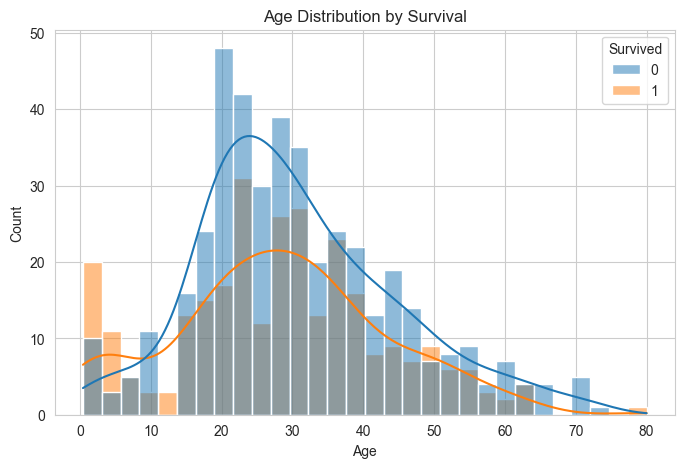

In [19]:
# 3.3: Age Analysis

# Age Distribution
# توزیع سن مسافران
plt.figure(figsize=(8,5))

sns.histplot(
    train["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

# ---------------------------------------

# Age vs Survival
plt.figure(figsize=(8,5))

sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Survival")
plt.show()

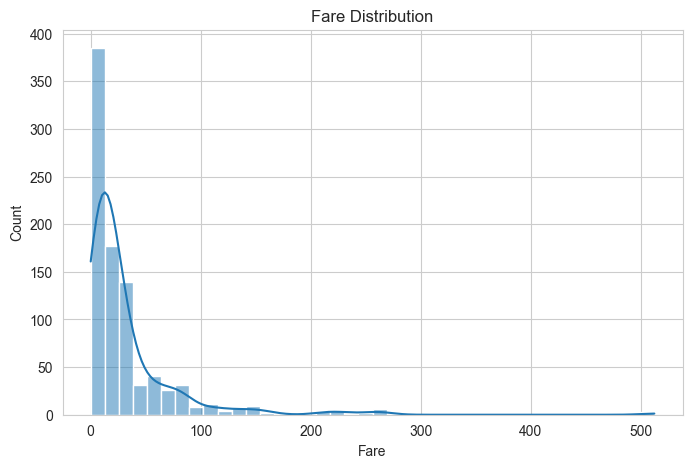

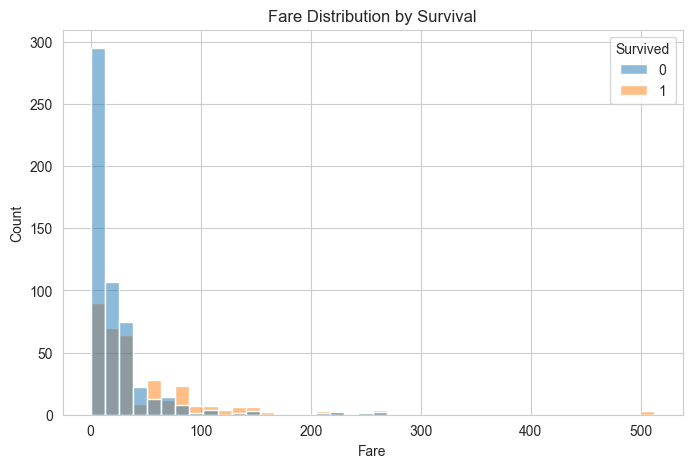

In [20]:
# 3.4: Fare Analysis

# Fare Distribution
# توزیع قیمت بلیط
plt.figure(figsize=(8,5))

sns.histplot(
    train["Fare"],
    bins=40,
    kde=True
)

plt.title("Fare Distribution")
plt.show()

# ----------------------------------------

# Fare vs Survival
plt.figure(figsize=(8,5))

sns.histplot(
    data=train,
    x="Fare",
    hue="Survived",
    bins=40
)

plt.title("Fare Distribution by Survival")
plt.show()

In [21]:
# 3.5: Family Analysis
# SibSp : # of siblings / spouses aboard the Titanic
# تعداد خواهر/برادر یا همسر همراه

print(train.groupby("SibSp")["Survived"].mean())

# ---------------------------------------

# Parch: # of parents / children aboard the Titanic
# تعداد والدین یا فرزندان همراه

print(train.groupby("Parch")["Survived"].mean())

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64
Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64


In [22]:
# ساخت Feature مهم FamilySize
# یکی از feature engineeringهای کلاسیک Titanic است.
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


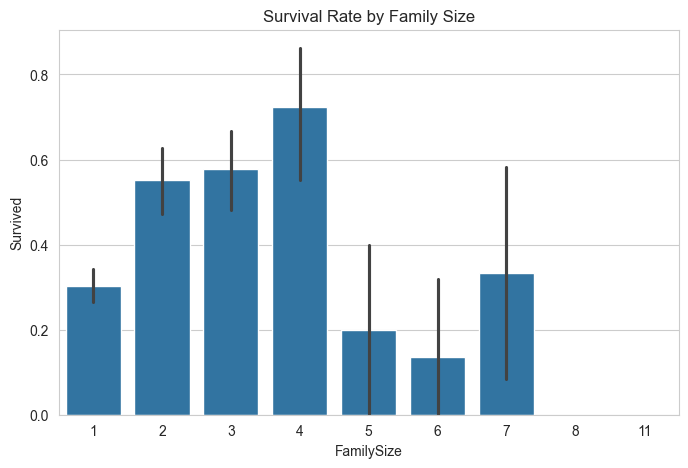

In [23]:
# 3.6: FamilySize vs Survival
print(train.groupby("FamilySize")["Survived"].mean())



plt.figure(figsize=(8,5))

sns.barplot(
    data=train,
    x="FamilySize",
    y="Survived"
)

plt.title("Survival Rate by Family Size")
plt.show()

### 4: Data Cleaning (Handling Missing Values)

In [24]:
# Concatenate Train و Test

# تعداد ردیف‌های train را نگه می‌داریم
# train_len برای جدا کردن دوباره دیتاست لازم است
train_len = len(train)

# برای اینکه بعداً بتوانیم دوباره جدا کنیم
# axis=0 ردیف‌ها به هم اضافه شوند.
# ignore_index=True باعث می‌شود index جدید ساخته شود.
full = pd.concat([train, test], axis=0, ignore_index=True)


print("Full dataset shape:", full.shape)

Full dataset shape: (1309, 13)


In [25]:
# برسی missing values

missing_values = full.isnull().sum().sort_values(ascending=False)

print(missing_values)

Cabin          1014
FamilySize      418
Survived        418
Age             263
Embarked          2
Fare              1
Name              0
Pclass            0
PassengerId       0
Sex               0
Ticket            0
SibSp             0
Parch             0
dtype: int64


In [26]:
# Impute Age with median
# Age distribution skewed است و median نسبت به outlier مقاوم‌تره.

age_median = full["Age"].median()

full["Age"] = full["Age"].fillna(age_median)

In [27]:
# Impute Embarked with mode
# ستون Embarked تعداد کمی Missing دارد پس از mode استفاده میکنیم.

embarked_mode = full["Embarked"].mode()[0]

# پر کردن مقدارهای خالی
full["Embarked"] = full["Embarked"].fillna(embarked_mode)

In [28]:
# Impute Fare with median
# در دیتاست Titanic فقط یک مقدار در test خالی است.

fare_median = full["Fare"].median()

full["Fare"] = full["Fare"].fillna(fare_median)

### 5: Feature Engineering

In [29]:
# 5.1: FamilySize

# SibSp = siblings/spouse
# Parch = parents/children
# FamilySize = SibSp + Parch + 1
# 1 برای خود شخص

full["FamilySize"] = full["SibSp"] + full["Parch"] + 1

In [30]:
# 5.2: IsAlone

# اگر FamilySize == 1 یعنی شخص تنها سفر کرده

full["IsAlone"] = (full["FamilySize"] == 1).astype(int)

In [31]:
# 5.3 استخراج Title از Name
# Like: Mr, Mrs, Miss, Master, Dr

full["Title"] = full["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

In [32]:
# گروه‌بندی Title های نادر :

rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]

full["Title"] = full["Title"].replace(rare_titles, "Rare")

full["Title"] = full["Title"].replace({
    "Mlle":"Miss",
    "Ms":"Miss",
    "Mme":"Mrs"
})


In [33]:
# 5.4: استخراج Deck از Cabin
# چون Cabin زیاد null دارد، Deck نیز برای خیلی‌ها NaN خواهد بود، ولی برای یک سری مسافر اطلاعات مفیدی می‌دهد.
# Cabin NaN --> Deck = "Unknown"
# فرض: Cabin like "C85" → deck = "C"

full["Deck"] = full["Cabin"].apply(lambda x: x[0] if pd.notna(x) else "Unknown")

In [34]:
# 5.5: FarePerPerson

full["FarePerPerson"] = full["Fare"] / full["FamilySize"]

In [35]:
# delete unnecessarily Columns
# reason to delete:
# cabin: اطلاعات خیلی sparse
# Ticket: الگوی خاصی نداره
# Name: قبلا Title ازش استخراج شده

columns_to_drop = ["Cabin", "Ticket", "Name"]

full = full.drop(columns=columns_to_drop)

In [36]:
# Check final dataset

print(full.head())
print(full.info())

   PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch     Fare  \
0            1       0.0       3    male  22.0      1      0   7.2500   
1            2       1.0       1  female  38.0      1      0  71.2833   
2            3       1.0       3  female  26.0      0      0   7.9250   
3            4       1.0       1  female  35.0      1      0  53.1000   
4            5       0.0       3    male  35.0      0      0   8.0500   

  Embarked  FamilySize  IsAlone Title     Deck  FarePerPerson  
0        S           2        0    Mr  Unknown        3.62500  
1        C           2        0   Mrs        C       35.64165  
2        S           1        1  Miss  Unknown        7.92500  
3        S           2        0   Mrs        C       26.55000  
4        S           1        1    Mr  Unknown        8.05000  
<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -

In [37]:
# جدا کردن دوباره full به train و test
train_clean = full.iloc[:train_len].copy()
test_clean = full.iloc[train_len:].copy()

# حذف ستون target از test
if "Survived" in test_clean.columns:
    test_clean = test_clean.drop("Survived", axis=1)

print("Train clean shape:", train_clean.shape)
print("Test clean shape:", test_clean.shape)


Train clean shape: (891, 14)
Test clean shape: (418, 13)


### 6: PREPROCESSING
Train/Test Split &
Encoding & 
Scalling 


In [38]:
X = train_clean.drop("Survived", axis=1)
y = train_clean["Survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 13)
y shape: (891,)


In [39]:
numerical_features = ["Pclass","Age","SibSp","Parch","Fare","FamilySize","IsAlone","FarePerPerson"]

categorical_features = ["Sex","Embarked","Title","Deck"]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
Categorical features: ['Sex', 'Embarked', 'Title', 'Deck']


In [40]:
# چرا stratify=y --> چون در Titanic کلاس‌ها imbalance هستند: Survived = 0 or 1
# و می‌خواهیم نسبت آن‌ها در train و validation حفظ شود.

X_train, X_val, y_train, y_val  = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_validation shape:", X_val.shape)

X_train shape: (712, 13)
X_validation shape: (179, 13)


In [41]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
# handle_unknown="ignore" --> اگر در test یک category جدید بیاید مدل error نمی‌دهد.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [42]:
# تست Preprocessor روی داده

X_train_processed = preprocessor.fit_transform(X_train)

print("Processed train shape:", X_train_processed.shape)

# اگر این سلول درست اجرا شه --> Encoding & Scaling & ColumnTransformer درسته

Processed train shape: (712, 27)


### 7: Modeling

In [43]:
# تابع ارزیابی مدل با Cross Validation

def evaluate_model(model):
    """
    مدل را همراه با Preprocessor در یک Pipeline قرار می‌دهد،
    سپس با Cross-Validation ارزیابی می‌کند.
    خروجی: میانگین accuracy
    """

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    print(f"Accuracies in 5 folds: {scores}")
    print(f"Mean Accuracy: {scores.mean():.4f}")

    return scores.mean()

In [44]:
# Logistic Regression (Baseline)

lr_model = LogisticRegression(max_iter=2000)

lr_score = evaluate_model(lr_model)

Accuracies in 5 folds: [0.82122905 0.81460674 0.81460674 0.81460674 0.86516854]
Mean Accuracy: 0.8260


In [45]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

rf_score = evaluate_model(rf_model)

Accuracies in 5 folds: [0.84357542 0.80337079 0.84831461 0.79775281 0.84269663]
Mean Accuracy: 0.8271


In [46]:
# XGBoost

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)

xgb_score = evaluate_model(xgb_model)

Accuracies in 5 folds: [0.82122905 0.80898876 0.86516854 0.8258427  0.84831461]
Mean Accuracy: 0.8339


In [47]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [lr_score, rf_score, xgb_score]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.826044
1        Random Forest  0.827142
2              XGBoost  0.833909


### 8: Hyperparameter Tuning with GridSearchCV (روی XGBoost و RandomForest)

In [48]:
# A) Hyperparameter Tuning برای XGBoost

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# ساخت pipeline برای XGBoost (با preprocessor)
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_base)
])

# تعریف فضای جستجو برای hyperparameters
param_grid_xgb = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

# GridSearchCV با cross-validation
grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=5,                # 5-fold CV
    scoring="accuracy",  # میتونم precision/recall هم تست کنم
    n_jobs=-1,
    verbose=2
)

# آموزش GridSearch روی کل X, y (نه فقط X_train)
grid_xgb.fit(X, y)

print("Best XGBoost params:", grid_xgb.best_params_)
print("Best XGBoost CV score:", grid_xgb.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best XGBoost params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 1.0}
Best XGBoost CV score: 0.8417738999435063


In [ ]:
# B) Hyperparameter Tuning برای RandomForest

rf_base = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_base)
])

param_grid_rf = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X, y)

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV score:", grid_rf.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


### 9: Feature Importance (RandomForest & XGBoost)

In [ ]:
# استخراج نام Features نهایی پس از preprocessor

numerical_features = ["Pclass","Age","SibSp","Parch","Fare","FamilySize","IsAlone","FarePerPerson"]
categorical_features = ["Sex","Embarked","Title","Deck"]

# گرفتن نام feature های عددی (همون قبلیا هستند)
num_features_out = numerical_features

# گرفتن نام feature های one-hot شده
# OneHotEncoder را از preprocessor بیرون می‌کشیم
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

# ترکیب همه features
all_feature_names = np.concatenate([num_features_out, cat_feature_names])

len(all_feature_names), all_feature_names[:10]

(27,
 array(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone',
        'FarePerPerson', 'Sex_female', 'Sex_male'], dtype=object))

In [ ]:
# Feature Importance for RandomForest (با مدل Tuned)

# استفاده از بهترین مدل RandomForest
best_rf_pipeline = grid_rf.best_estimator_
best_rf_model = best_rf_pipeline.named_steps["model"]

# feature_importances_ از مدل
rf_importances = best_rf_model.feature_importances_

# ساخت DataFrame مرتب شده
rf_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_importances
}).sort_values(by="importance", ascending=False)

rf_importance_df.head(20)

,feature,importance
9,Sex_male,0.145445
8,Sex_female,0.128415
7,FarePerPerson,0.109426
15,Title_Mr,0.109255
4,Fare,0.099741
1,Age,0.084190
0,Pclass,0.067455
5,FamilySize,0.045228
16,Title_Mrs,0.032986
14,Title_Miss,0.031811


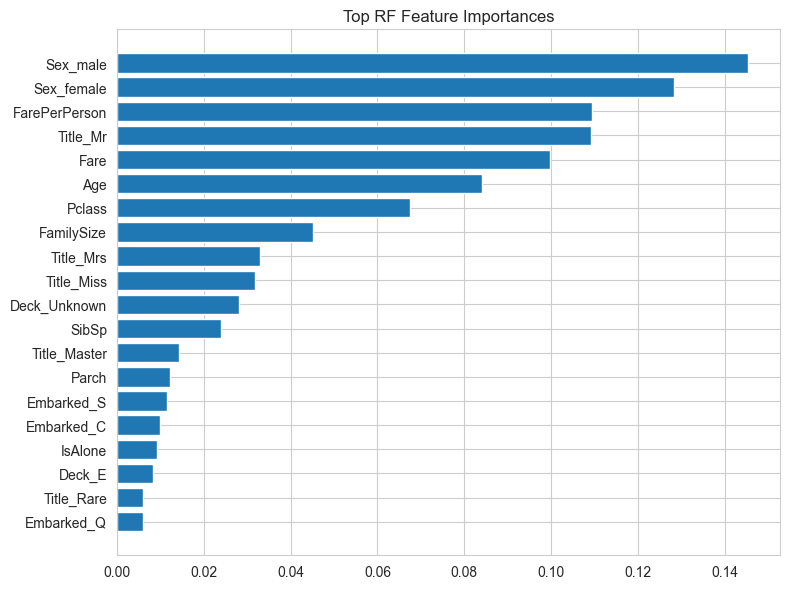

In [ ]:
# Visualize Feature Importance for RF

top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(
    rf_importance_df["feature"].iloc[:top_n][::-1],
    rf_importance_df["importance"].iloc[:top_n][::-1]
)
plt.title("Top RF Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# Feature Importance for XGBoost

best_xgb_pipeline = grid_xgb.best_estimator_
best_xgb_model = best_xgb_pipeline.named_steps["model"]

xgb_importances = best_xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": xgb_importances
}).sort_values(by="importance", ascending=False)

xgb_importance_df.head(20)

,feature,importance
15,Title_Mr,0.511575
0,Pclass,0.125636
17,Title_Rare,0.066034
5,FamilySize,0.046145
26,Deck_Unknown,0.031320
22,Deck_E,0.022220
2,SibSp,0.021473
12,Embarked_S,0.021288
7,FarePerPerson,0.016862
20,Deck_C,0.016570


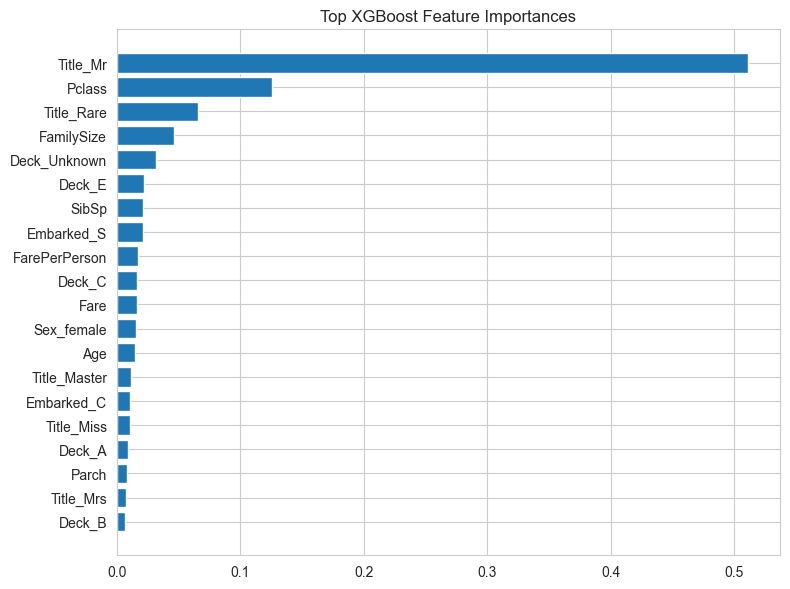

In [ ]:
# Visualize Feature Importance for XGBoost

plt.figure(figsize=(8, 6))
plt.barh(
    xgb_importance_df["feature"].iloc[:top_n][::-1],
    xgb_importance_df["importance"].iloc[:top_n][::-1]
)
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# conclusion:
# جنسیت، کرایه، عنوان، کلاس، سن و اندازه خانواده مهم‌ترین عوامل زنده ماندن بوده‌اند.
# Sex_male, Sex_female --> جنسیت فوق‌العاده مهم
# FarePerPerson, Fare --> وضعیت اقتصادی/بلیت مهم
# Title_Mr, Title_Miss, Title_Mrs, Title_Master --> عنوان اجتماعی (سن/جنس/طبقه)
# Age, Pclass, FamilySize, IsAlone --> مطابق انتظار
# Deck_Unknown و بعضی deckها هم سیگنال دارند
# Title_Mr نصف مدل را می‌بلعد (0.51 importance)یعنی مدل از این feature خیلی سیگنال گرفته.

### 10: Learning Curve

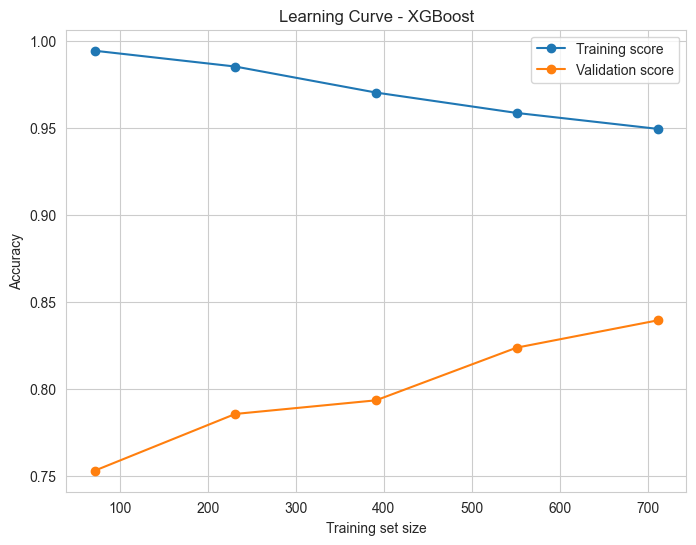

In [ ]:
# Learning Curve برای XGBoost
# میفهمیم overfitting / underfitting داریم یا نه
# و اینکه آیا با داده بیشتر performance بهتر میشه یا saturation شده.


# مدل نهایی XGBoost با بهترین params (مثل grid_xgb)
final_xgb_pipeline = grid_xgb.best_estimator_

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=final_xgb_pipeline,
    X=X,
    y=y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, "o-", label="Training score")
plt.plot(train_sizes, valid_mean, "o-", label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Train score بالا &  Validation پایین‌تر --> overfitting ولی کمه و البته طبیعیه برای XGBoost روی دیتاست کوچیک titanic و فاصله خیلی فاجعه نیست
# با زیاد شدن داده Validation score بالا می‌رود در نتیجه مدل از داده بیشتر سود می‌برد که این خوب است.

### 11: Voting & Stacking + Cross-Validation Comparison

In [ ]:
# 1) Logistic Regression (base)
logreg_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_scores = cross_val_score(
    logreg_clf, X, y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


# 2) RandomForest (tuned)
# از best_estimator_ که خودش یک Pipeline است استفاده می‌کنیم
rf_clf = grid_rf.best_estimator_
rf_scores = cross_val_score(
    rf_clf, X, y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


# 3) XGBoost (base)

xgb_base_clf = xgb_pipeline   # اگر تعریف نشده، این خط را اصلاح کن یا حذف
xgb_base_scores = cross_val_score(
    xgb_base_clf, X, y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


# 4) XGBoost (tuned)
xgb_tuned_clf = grid_xgb.best_estimator_
xgb_tuned_scores = cross_val_score(
    xgb_tuned_clf, X, y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [ ]:
# 5) Voting Classifier
# برای Voting معمولاً base estimators را بدون preprocessor میزاریم,
# و preprocessor را در یک Pipeline بیرونی قرار میدیم.

voting_estimators = [
    ("lr", LogisticRegression(max_iter=1000)),
    ("rf", rf_clf.named_steps["model"]),
    ("xgb", xgb_tuned_clf.named_steps["model"])
]

voting_model = VotingClassifier(
    estimators=voting_estimators,
    voting="soft",
    n_jobs=-1
)

voting_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", voting_model)
])

voting_scores = cross_val_score(
    voting_clf, X, y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [ ]:
# 6) Stacking Classifier
# -----------------------------
stacking_estimators = [
    ('rf', rf_clf.named_steps['model']),
    ('xgb', xgb_tuned_clf.named_steps['model']),
    ('lr', LogisticRegression(max_iter=1000))
]

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

stacking_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", stacking_model)
])

stacking_scores = cross_val_score(
    stacking_clf, X, y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [ ]:
# 7) ساخت جدول نتایج

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest (tuned)",
        "XGBoost (base)",
        "XGBoost (tuned)",
        "Voting",
        "Stacking"
    ],
    "CV_Accuracy": [
        logreg_scores.mean(),
        rf_scores.mean(),
        xgb_base_scores.mean(),
        xgb_tuned_scores.mean(),
        voting_scores.mean(),
        stacking_scores.mean()
    ]
})

results = results.sort_values(by="CV_Accuracy", ascending=False).reset_index(drop=True)

print("Cross-Validation Results:")
results

Cross-Validation Results:


,Model,CV_Accuracy
0,Voting,0.845126
1,Stacking,0.842872
2,XGBoost (tuned),0.841774
3,XGBoost (base),0.836156
4,Random Forest (tuned),0.836118
5,Logistic Regression,0.826044


### 12: Final Model Training & Prediction & Submission

In [ ]:
# Final Model Training
# برای حداکثر استفاده از داده‌ها، مدل را روی کل dataset train می‌کنیم.

# 1. انتخاب بهترین مدل بر اساس Cross-Validation
best_model = voting_clf
print("Training BEST model (Voting Classifier) on full dataset...")

# آموزش روی کل داده train
best_model.fit(X, y)

print("Final training completed.")

Training BEST model (Voting Classifier) on full dataset...
Final training completed.


In [ ]:
# 2. save model in models

MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

model_save_path = os.path.join(MODELS_DIR, "voting_clf_model.pkl")
joblib.dump(best_model, model_save_path)
print(f"Model saved successfully at: {model_save_path}")

Model saved successfully at: c:\Users\ASUS\Downloads\Machine Learning\ML Algorithm\Titanic\models\voting_clf_model.pkl


In [ ]:
# Final Prediction on test_clean

test_predictions = best_model.predict(test_clean)

print("Prediction completed.")
print("Sample predictions:", test_predictions[:10])

Prediction completed.
Sample predictions: [0. 0. 0. 0. 1. 0. 0. 0. 1. 0.]


In [ ]:
# Build Submission File

# ۳. پیش‌بینی و ذخیره سابمیشن در پوشه اصلی (Root)
test_predictions = best_model.predict(test_clean)

submission_path = os.path.join(BASE_DIR, "submission.csv")
submission = pd.DataFrame({
    "PassengerId": test_clean["PassengerId"],
    "Survived": test_predictions.astype(int)
})

submission.to_csv(submission_path, index=False)
print(f"Submission file created successfully at: {submission_path}")

print("Submission file created successfully!")
# نمایش خروجی برای اطمینان
display(submission.head())
display(submission.tail())
print("Submission shape:", submission.shape)

Submission file created successfully at: c:\Users\ASUS\Downloads\Machine Learning\ML Algorithm\Titanic\submission.csv
Submission file created successfully!


,PassengerId,Survived
891,892,0
892,893,0
893,894,0
894,895,0
895,896,1


,PassengerId,Survived
1304,1305,0
1305,1306,1
1306,1307,0
1307,1308,0
1308,1309,1


Submission shape: (418, 2)


# Conclusion

In this project, multiple machine learning models were trained and evaluated on the Titanic dataset.

The models included:
- Logistic Regression
- Random Forest
- XGBoost
- Voting Ensemble
- Stacking Ensemble

After hyperparameter tuning and cross-validation evaluation, the Voting Classifier achieved the best performance with the highest average CV accuracy.

## Key Findings

- Ensemble learning significantly improved performance compared to single models.
- Tuned XGBoost and Random Forest were strong base learners.
- Soft Voting produced better generalization than Stacking on this dataset.
- The dataset size is relatively small, which may explain why the simpler ensemble method generalized better.

## Future Improvements

Possible future improvements include:

- Advanced feature engineering:
  - AgeGroup
  - FareBin
  - FamilySize
  - Interaction features
- Trying LightGBM or CatBoost
- Probability calibration
- Feature selection and dimensionality reduction
